In [2]:
import os
import json
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import ast
import re

import requests
from collections import Counter
tqdm.pandas()

pd.set_option('display.max_columns', None)

### Обработка 

In [1]:
def clean_html_re(text):
    """Удаляет HTML теги через регулярку"""
    if not isinstance(text, str):
        return ""
    # Удаляем теги
    text = re.sub(r'<[^>]+>', ' ', text)
    # Удаляем лишние пробелы
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def get_field(x, field):
    if pd.isna(x) or not x:
        return None
    try:
        return ast.literal_eval(x).get(field, None)
    except:
        return None

In [4]:
dataset_list=[]

for dataset_name in tqdm(os.listdir('dataset')):
    df = pd.read_parquet(f'dataset/{dataset_name}')
    df['category'] = dataset_name.split('.')[0]
    dataset_list.append(df)

df = pd.concat(dataset_list).reset_index(drop=True)

bool_columns = [
    'premium',
    'has_test',
    'response_letter_required',
    'show_logo_in_search',
    'accept_temporary',
    'accept_incomplete_resumes',
    'archived'
    ]

no_info_columns = [
    'response_url',
    'sort_point_distance',
    'apply_alternate_url',
    'insider_interview',
    'url',
    'is_adv_vacancy',
    'relations',
    'contacts',
    'working_days',
    'working_time_intervals',
    'working_time_modes',
    'adv_response_url',
    'adv_context',
    'area',
    'snippet'
]

df.drop(
   no_info_columns,
   axis=1,
   inplace=True 
)

df[bool_columns] = df[bool_columns].astype(bool)
df['description'] = df['description'].apply(clean_html_re)
df['department'] = df['department'].apply(lambda x: get_field(x, 'name'))
df['employer_name'] = df['employer'].apply(lambda x: get_field(x, 'name'))
df['accredited_it_employer'] = df['employer'].apply(lambda x: get_field(x, 'accredited_it_employer'))
df['trusted'] = df['employer'].apply(lambda x: get_field(x, 'trusted'))

df.drop(
    'employer',
    axis=1,
    inplace=True
)

df['salary_from'] = df['salary'].apply(lambda x: get_field(x, 'from_'))
df['salary_to'] = df['salary'].apply(lambda x: get_field(x, 'to'))
df['salary_currency'] = df['salary'].apply(lambda x: get_field(x, 'currency'))
df['salary_gross'] = df['salary'].apply(lambda x: get_field(x, 'gross'))
df.drop(
    'salary',
    axis=1,
    inplace=True
)

df['schedule'] = df['schedule'].apply(lambda x: get_field(x, 'id'))
df['professional_roles'] = df['professional_roles'].str[1:-1].apply(lambda x: get_field(x, 'name'))
df['experience'] = df['experience'].apply(lambda x: get_field(x, 'id'))
df['employment'] = df['employment'].apply(lambda x: get_field(x, 'id'))
df['type_'] = df['type_'].apply(lambda x: get_field(x, 'id'))

df['address_city'] = df['address'].apply(lambda x: get_field(x, 'city'))
df['address_street'] = df['address'].apply(lambda x: get_field(x, 'street'))
df['address_lat'] = df['address'].apply(lambda x: get_field(x, 'lat'))
df['address_lng'] = df['address'].apply(lambda x: get_field(x, 'lng'))
df.drop(
    'address',
    axis=1,
    inplace=True
)

100%|██████████| 11/11 [00:01<00:00,  5.80it/s]


### Восстановление всех поисковых тегов

In [5]:
all_items = []

for spec in os.listdir("data"):
    spec_path = f"data/{spec}"
    if not os.path.isdir(spec_path):
        continue
    
    print(f"\n📁 {spec}")
    
    for file in tqdm(os.listdir(spec_path)):
        if not file.endswith('.parquet'):
            continue
            
        # Читаем файл
        df = pd.read_parquet(f"{spec_path}/{file}")
        
        # Добавляем колонку с тегом (имя файла)
        df['search_tag'] = file.replace('.parquet', '')
        df['category'] = spec
        
        all_items.append(df)

all_items = pd.concat(all_items).reset_index(drop=True)


📁 Data Engineering


100%|██████████| 12/12 [00:00<00:00, 45.16it/s]



📁 DevOps и инфраструктура


100%|██████████| 29/29 [00:01<00:00, 25.46it/s]



📁 Аналитик


...

100%|██████████| 37/37 [00:01<00:00, 35.00it/s]



📁 Тестировщик


100%|██████████| 15/15 [00:00<00:00, 22.35it/s]



📁 Технический специалист


100%|██████████| 17/17 [00:00<00:00, 30.62it/s]


In [6]:
all_items['id'] = all_items['id'].astype(int)
all_tags = all_items.groupby('id', as_index=False)['search_tag'].agg(list)
all_categories = all_items.groupby('id', as_index=False)['category'].agg(list)

In [7]:
tag_dict = all_tags.set_index('id')['search_tag'].to_dict()
category_dict = all_categories.set_index('id')['category'].to_dict()

In [8]:
df['search_tag'] = df['id'].map(tag_dict)
df['category'] = df['id'].map(category_dict)
df.drop_duplicates(
    'id',
    inplace=True
)

### Обработка случаев, когда тега нет в названии вакансии

In [9]:
target_tags = ['Technical Support']

# Проверяем, что есть хотя бы одно совпадение
df_filtered = df[
    ~df['search_tag'].apply(lambda tags: any(tag in target_tags for tag in tags))
    ]

df_filtered = df_filtered[
    ~(df_filtered['name'].str.lower().str.contains('переводчик'))
]

In [10]:
def delete_category(row):
    category_list = row['search_tag']
    if isinstance(category_list, list):
        return [cat for cat in category_list if cat != 'Блокчейн разработчик']
    return category_list

df_filtered['search_tag'] = df_filtered.apply(delete_category, axis=1)


In [11]:
df_filtered['category_result'] = df_filtered['category'].apply(
    lambda x: Counter(x).most_common(1)[0][0]
)

In [12]:
df_filtered['search_tag'] = df_filtered['search_tag'].astype(str)

### Ресерч

In [3]:
dataset = pd.read_parquet('dataset/cooked.parquet')

In [15]:
dataset.groupby(['category_result'], as_index=False)['id'].nunique()

,category_result,id
0,Data Engineering,537
1,DevOps и инфраструктура,4742
2,Аналитик,3979
3,Безопасность,1903
4,Искусственный интеллект,1535
5,Менеджер,6336
6,Новые профессии,51
7,Разработчик,5668
8,Тестировщик,3741
9,Технический специалист,727


In [17]:
dataset.groupby('category_result')['salary_from'].apply(lambda x: x.isna().mean())

category_result
Data Engineering           0.878957
DevOps и инфраструктура    0.553775
Аналитик                   0.790902
Безопасность               0.647399
Искусственный интеллект    0.657980
Менеджер                   0.587121
Новые профессии            0.784314
Разработчик                0.625970
Тестировщик                0.557338
Технический специалист     0.693260
Name: salary_from, dtype: float64

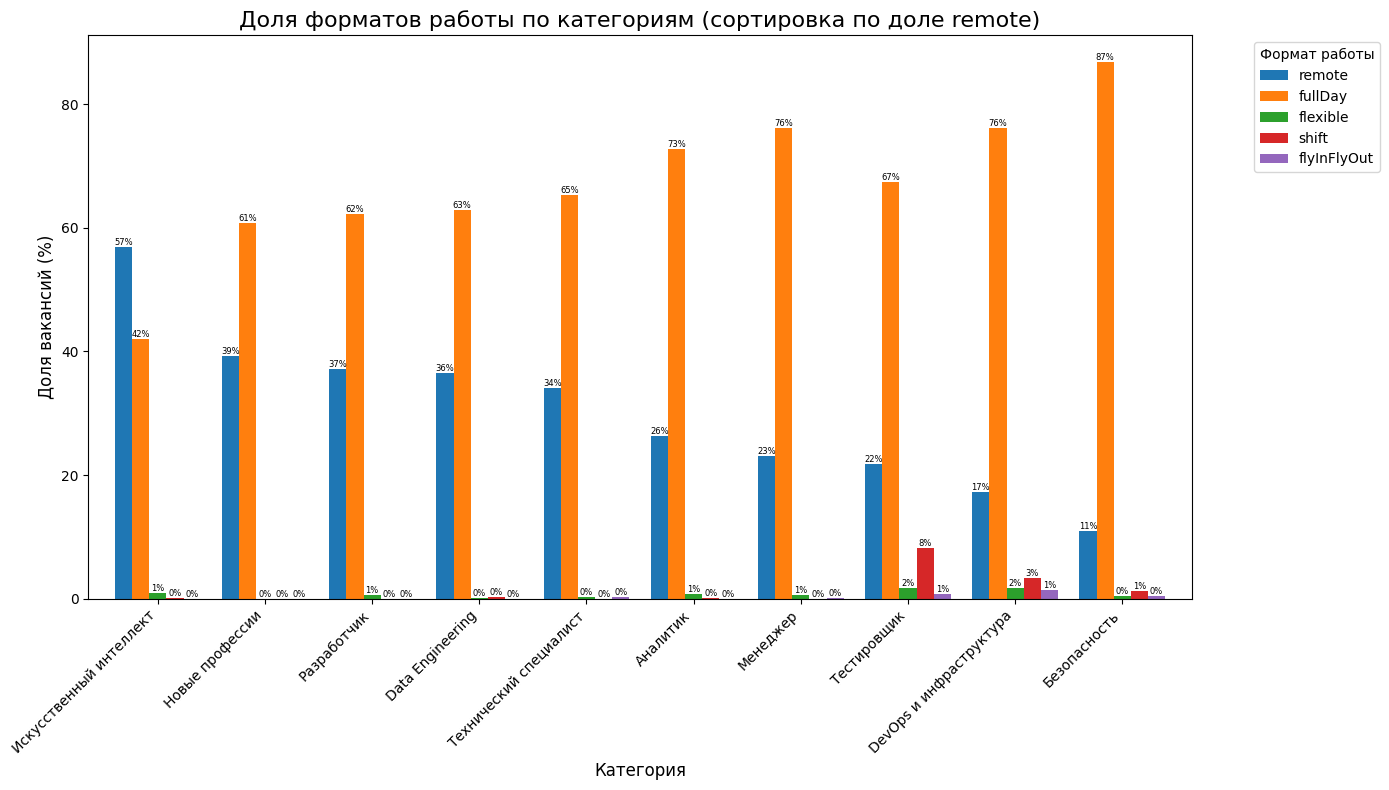

In [18]:
data = dataset.groupby(['category_result', 'schedule'])['id'].nunique()

# Преобразуем в DataFrame
df_plot = data.reset_index()
df_plot.columns = ['category', 'schedule', 'count']

# Сводная таблица
pivot = df_plot.pivot(index='category', columns='schedule', values='count').fillna(0)

# Нормализуем по строкам (доля внутри каждой категории)
pivot_normalized = pivot.div(pivot.sum(axis=1), axis=0) * 100

# СОРТИРУЕМ ПО ДОЛЕ REMOTE (убывание)
sort_by = 'remote'
pivot_normalized = pivot_normalized.sort_values(by=sort_by, ascending=False)

# Сортируем колонки внутри групп по убыванию
column_order = pivot_normalized.iloc[0].sort_values(ascending=False).index
pivot_normalized = pivot_normalized[column_order]

# Визуализация
fig, ax = plt.subplots(figsize=(14, 8))

pivot_normalized.plot(kind='bar', ax=ax, width=0.8)

plt.title(f'Доля форматов работы по категориям (сортировка по доле {sort_by})', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Доля вакансий (%)', fontsize=12)
plt.legend(title='Формат работы', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='edge', fontsize=6)

plt.tight_layout()
plt.show()

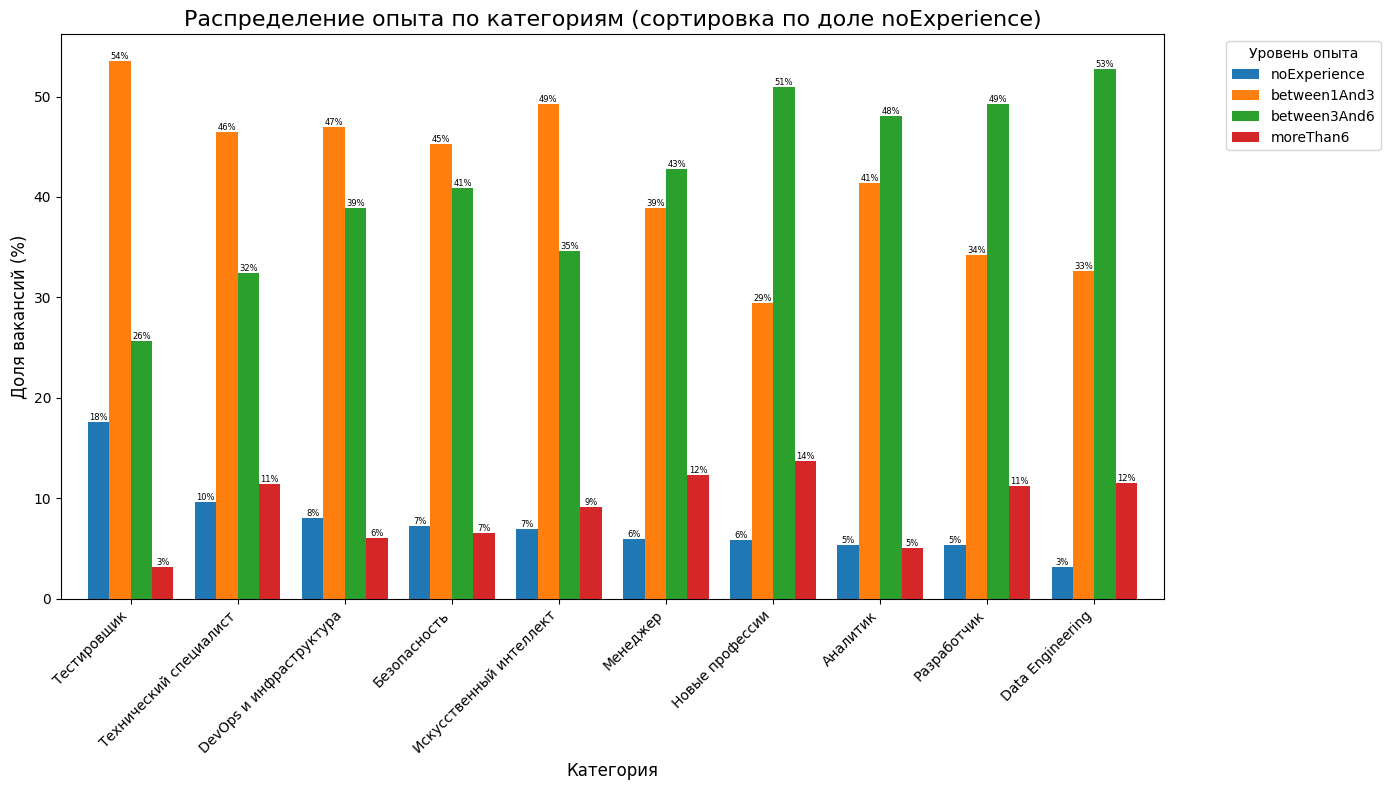

In [19]:
data = dataset.groupby(['category_result', 'experience'])['id'].nunique()

# Преобразуем в DataFrame
df_plot = data.reset_index()
df_plot.columns = ['category', 'experience', 'count']

# Сводная таблица
pivot = df_plot.pivot(index='category', columns='experience', values='count').fillna(0)

# Нормализуем по строкам (доля внутри каждой категории)
pivot_normalized = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Задаем порядок колонок (уровней опыта) вручную
experience_order = ['noExperience', 'between1And3', 'between3And6', 'moreThan6']
# Оставляем только те колонки, которые есть в данных
experience_order = [col for col in experience_order if col in pivot_normalized.columns]
pivot_normalized = pivot_normalized[experience_order]

# СОРТИРУЕМ КАТЕГОРИИ по доле noExperience (или любому другому критерию)
sort_by = 'noExperience'  # можно заменить на 'between1And3' и т.д.
pivot_normalized = pivot_normalized.sort_values(by=sort_by, ascending=False)

# Визуализация
fig, ax = plt.subplots(figsize=(14, 8))

pivot_normalized.plot(kind='bar', ax=ax, width=0.8)

plt.title(f'Распределение опыта по категориям (сортировка по доле {sort_by})', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Доля вакансий (%)', fontsize=12)
plt.legend(title='Уровень опыта', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='edge', fontsize=6)

plt.tight_layout()
plt.show()

In [20]:
data = dataset.groupby(['category_result', 'experience'])['id'].nunique()

# Преобразуем в DataFrame
df_plot = data.reset_index()
df_plot.columns = ['category', 'experience', 'count']

# Сводная таблица
pivot = df_plot.pivot(index='category', columns='experience', values='count').fillna(0)

# Нормализуем по строкам (доля внутри каждой категории)
pivot_normalized = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Задаем порядок колонок (уровней опыта) вручную
experience_order = ['noExperience', 'between1And3', 'between3And6', 'moreThan6']
# Оставляем только те колонки, которые есть в данных
experience_order = [col for col in experience_order if col in pivot_normalized.columns]
pivot_normalized = pivot_normalized[experience_order]

# СОРТИРУЕМ КАТЕГОРИИ по доле noExperience (или любому другому критерию)
sort_by = 'noExperience'  # можно заменить на 'between1And3' и т.д.
pivot_normalized = pivot_normalized.sort_values(by=sort_by, ascending=False)

# Подготовка данных для Plotly
# Преобразуем DataFrame в длинный формат (melt)
df_plotly = pivot_normalized.reset_index().melt(
    id_vars=['category'], 
    var_name='experience', 
    value_name='share'
)

# Переименовываем значения опыта для красивого отображения
experience_labels = {
    'noExperience': 'Без опыта',
    'between1And3': '1-3 года',
    'between3And6': '3-6 лет',
    'moreThan6': 'Более 6 лет'
}
df_plotly['experience'] = df_plotly['experience'].map(experience_labels)

# Визуализация через Plotly Express
fig = px.bar(
    df_plotly,
    x='category',
    y='share',
    color='experience',
    title=f'Распределение требуемового опыта по категориям',
    labels={
        'category': 'Категория',
        'share': 'Доля вакансий (%)',
        'experience': 'Уровень опыта'
    },
    barmode='group',
    text_auto='.0f',
    color_discrete_sequence=px.colors.qualitative.Set2
)

# Настройка внешнего вида
fig.update_layout(
    xaxis_tickangle=-45,
    height=600,
    width=1000,
    hovermode='x unified',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1,
        title='Уровень опыта'
    ),
    bargap=0.2
)

# Настройка текста на столбцах
fig.update_traces(
    textposition='outside',
    textfont_size=10,
    cliponaxis=False
)

# # Настройка осей
# fig.update_yaxis(ticksuffix='%', range=[0, 100])

# # Показываем график
# fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'cliponaxis': False,
              'hovertemplate': ('Уровень опыта=Без опыта<br>Кат' ... 'кансий (%)=%{y}<extra></extra>'),
              'legendgroup': 'Без опыта',
              'marker': {'color': 'rgb(102,194,165)', 'pattern': {'shape': ''}},
              'name': 'Без опыта',
              'offsetgroup': 'Без опыта',
              'orientation': 'v',
              'showlegend': True,
              'textfont': {'size': 10},
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Тестировщик', 'Технический специалист', 'DevOps и инфраструктура',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Аналитик', 'Разработчик', 'Data Engineering'],
                         dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('kP7YAemPMUDrI/ZD2UEjQP4HEjNNJy' ... 'xqDJ0VQENX9aIqdBVAZrphK21TCUA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'cliponaxis': False,
              'hovertemplate': ('Уровень опыта=1-3 года<br>Кате' ... 'кансий (%)=%{y}<extra></extra>'),
              'legendgroup': '1-3 года',
              'marker': {'color': 'rgb(252,141,98)', 'pattern': {'shape': ''}},
              'name': '1-3 года',
              'offsetgroup': '1-3 года',
              'orientation': 'v',
              'showlegend': True,
              'textfont': {'size': 10},
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Тестировщик', 'Технический специалист', 'DevOps и инфраструктура',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Аналитик', 'Разработчик', 'Data Engineering'],
                         dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('7x5s5O7BSkB4f1oZCD9HQEwUbJ2aeE' ... 'kzN7JEQNJxujgWHUFA7WcWeVJLQEA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'cliponaxis': False,
              'hovertemplate': 'Уровень опыта=3-6 лет<br>Категория=%{x}<br>Доля вакансий (%)=%{y}<extra></extra>',
              'legendgroup': '3-6 лет',
              'marker': {'color': 'rgb(141,160,203)', 'pattern': {'shape': ''}},
              'name': '3-6 лет',
              'offsetgroup': '3-6 лет',
              'orientation': 'v',
              'showlegend': True,
              'textfont': {'size': 10},
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Тестировщик', 'Технический специалист', 'DevOps и инфраструктура',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Аналитик', 'Разработчик', 'Data Engineering'],
                         dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('2HAbew23OUBcfcR+KDtAQJ6Df2GTeU' ... 'L5Hw1IQMpZ15iinEhA8XG5s59ZSkA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'cliponaxis': False,
              'hovertemplate': ('Уровень опыта=Более 6 лет<br>К' ... 'кансий (%)=%{y}<extra></extra>'),
              'legendgroup': 'Более 6 лет',
              'marker': {'color': 'rgb(231,138,195)', 'pattern': {'shape': ''}},
              'name': 'Более 6 лет',
              'offsetgroup': 'Более 6 лет',
              'orientation': 'v',
              'showlegend': True,
              'textfont': {'size': 10},
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Тестировщик', 'Технический специалист', 'DevOps и ин

In [21]:
def plot_distribution(df, col, sort_by):
    """
    Визуализация распределения колонки по категориям
    
    Parameters:
    df - датафрейм
    col - колонка для анализа (experience, schedule и т.д.)
    sort_by - по какой колонке сортировать (например 'noExperience' или 'remote')
    """
    # Агрегируем
    data = df.groupby(['category_result', col])['id'].nunique()
    df_plot = data.reset_index()
    df_plot.columns = ['category', col, 'count']
    
    # Сводная таблица
    pivot = df_plot.pivot(index='category', columns=col, values='count').fillna(0)
    
    # Нормализуем
    pivot_normalized = pivot.div(pivot.sum(axis=1), axis=0) * 100
    
    # Сортируем по указанной колонке
    if sort_by in pivot_normalized.columns:
        pivot_normalized = pivot_normalized.sort_values(by=sort_by, ascending=False)
    
    # Подготовка для plotly
    df_plotly = pivot_normalized.reset_index().melt(id_vars=['category'], var_name=col, value_name='share')
    
    # График
    fig = px.bar(
        df_plotly,
        x='category',
        y='share',
        color=col,
        title=f'Распределение {col} по категориям',
        barmode='group',
        text_auto='.0f'
    )
    
    fig.update_layout(xaxis_tickangle=-45, height=600)
    fig.update_traces(textposition='outside')
    
    return fig

In [23]:
plot_distribution(dataset, 'employment', 'full')
# df_filtered.groupby(['category_result', 'employment'])['id'].nunique()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': 'employment=full<br>category=%{x}<br>share=%{y}<extra></extra>',
              'legendgroup': 'full',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'full',
              'offsetgroup': 'full',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Безопасность', 'Менеджер', 'Аналитик', 'DevOps и инфраструктура',
                          'Тестировщик', 'Data Engineering', 'Новые профессии', 'Разработчик',
                          'Технический специалист', 'Искусственный интеллект'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('UMFNIo+oWEAdx3Ecx4VYQPl9TjTZcF' ... '9DAfFXQN07msYUw1dASbMzNkWfVkA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'hovertemplate': 'employment=part<br>category=%{x}<br>share=%{y}<extra></extra>',
              'legendgroup': 'part',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'part',
              'offsetgroup': 'part',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Безопасность', 'Менеджер', 'Аналитик', 'DevOps и инфраструктура',
                          'Тестировщик', 'Data Engineering', 'Новые профессии', 'Разработчик',
                          'Технический специалист', 'Искусственный интеллект'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('r5j/rKbn6j9BrV8pUOvwP+l9cdSOfP' ... 'BpP1kCQJmtJXPvaPo/EGRYEm6UGkA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'hovertemplate': 'employment=project<br>category=%{x}<br>share=%{y}<extra></extra>',
              'legendgroup': 'project',
              'marker': {'color': '#00cc96', 'pattern': {'shape': ''}},
              'name': 'project',
              'offsetgroup': 'project',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Безопасность', 'Менеджер', 'Аналитик', 'DevOps и инфраструктура',
                          'Тестировщик', 'Data Engineering', 'Новые профессии', 'Разработчик',
                          'Технический специалист', 'Искусственный интеллект'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('br8fLMjQ4D9FF1100UXrP8wD7xckTf' ... 'M8MA3/P5mtJXPvaApAzc7YFH3uBkA='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'height': 600,
               'legend': {'title': {'text': 'employment'}, 'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Распределение employment по категориям'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'tickangle': -45, 'title': {'text': 'category'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'share'}}}
})

In [24]:
plot_distribution(dataset, 'has_test', 'True')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': 'has_test=False<br>category=%{x}<br>share=%{y}<extra></extra>',
              'legendgroup': 'False',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'False',
              'offsetgroup': 'False',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Data Engineering', 'DevOps и инфраструктура', 'Аналитик',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Разработчик', 'Тестировщик',
                          'Технический специалист'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAAAAAGRK5mg1VXQJOkRuIp/1' ... 'nrGlPEPwkjAJYwAldAp0q0ADLeVkA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'hovertemplate': 'has_test=True<br>category=%{x}<br>share=%{y}<extra></extra>',
              'legendgroup': 'True',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'True',
              'offsetgroup': 'True',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Data Engineering', 'DevOps и инфраструктура', 'Аналитик',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Разработчик', 'Тестировщик',
                          'Технический специалист'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAAWUCmvxuVyacaQGTbyu2wBi' ... 'py1vVYQGrP/Z/23B9Ayapd+m8OIUA='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'height': 600,
               'legend': {'title': {'text': 'has_test'}, 'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Распределение has_test по категориям'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'tickangle': -45, 'title': {'text': 'category'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'share'}}}
})

In [25]:
df_map = dataset.dropna(subset=['address_lat', 'address_lng']).copy()

fig = px.scatter_mapbox(
    df_map,
    lat='address_lat',
    lon='address_lng',
    color='category_result',
    hover_name='category_result',
    title='Распределение вакансий по миру',
    zoom=1,  # зум 1 = видно всю планету
    height=700,
    opacity=0.6
)

# Настройка стиля карты
fig.update_layout(
    mapbox_style="carto-positron",  
    mapbox_zoom=1,
    mapbox_center={"lat": 55, "lon": 60}  # центрируем на Россию/Евразию
)

# fig.show()

C:\Users\aleks\AppData\Local\Temp\ipykernel_24224\3840784910.py:3: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': ('<b>%{hovertext}</b><br><br>cat' ... 'ress_lng=%{lon}<extra></extra>'),
              'hovertext': array(['Data Engineering', 'Data Engineering', 'Data Engineering', ...,
                                  'Data Engineering', 'Data Engineering', 'Data Engineering'],
                                 shape=(367,), dtype=object),
              'lat': {'bdata': ('TYV4JF6eRUBtH/KWq41HQBiYFYp0jU' ... 'GL+eNLQPA0mfG22ERAKV36l6TgS0A='),
                      'dtype': 'f8'},
              'legendgroup': 'Data Engineering',
              'lon': {'bdata': ('nuv7cJA6U0C/RpIgXPVJQHcstklF80' ... 'wRiZJIQOFfBI2ZZkZAZVOu8C7BQkA='),
                      'dtype': 'f8'},
              'marker': {'color': '#636efa', 'opacity': 0.6},
              'mode': 'markers',
              'name': 'Data Engineering',
              'showlegend': True,
              'subplot': 'mapbox',
              'type': 'scattermapbox'},
             {'hovertemplate': ('<b>%{hovertext}</b><br><br>cat' ... 'ress_lng=%{lon}<extra></extra>'),
              'hovertext': array(['Искусственный интеллект', 'Искусственный интеллект',
                                  'Искусственный интеллект', ..., 'Искусственный интеллект',
                                  'Искусственный интеллект', 'Искусственный интеллект'],
                                 shape=(784,), dtype=object),
              'lat': {'bdata': ('ToBh+fPfS0B0YaQXtTdKQCJt409Uuk' ... 'M0nthLQPNWXYdq2ktA4+DSMefnTEA='),
                      'dtype': 'f8'},
              'legendgroup': 'Искусственный интеллект',
              'lon': {'bdata': ('FeEmo8rEQkDJOEayRwA/QGWMD7OXVF' ... 'l63dRCQPNaCd0l20JAf/eOGhNaPEA='),
                      'dtype': 'f8'},
              'marker': {'color': '#EF553B', 'opacity': 0.6},
              'mode': 'markers',
              'name': 'Искусственный интеллект',
              'showlegend': True,
              'subplot': 'mapbox',
              'type': 'scattermapbox'},
             {'hovertemplate': ('<b>%{hovertext}</b><br><br>cat' ... 'ress_lng=%{lon}<extra></extra>'),
              'hovertext': array(['DevOps и инфраструктура', 'DevOps и инфраструктура',
                                  'DevOps и инфраструктура', ..., 'DevOps и инфраструктура',
                                  'DevOps и инфраструктура', 'DevOps и инфраструктура'],
                                 shape=(4082,), dtype=object),
              'lat': {'bdata': ('B+5AnfKcRUBQi8HDtCNEQADEXb2K2E' ... 'ggoUtATkUqjC0sS0BORSqMLSxLQA=='),
                      'dtype': 'f8'},
              'legendgroup': 'DevOps и инфраструктура',
              'lon': {'bdata': ('V7Q5zm07U0B7pMFtbWhRQGoSvCGN1E' ... 'awsk5A5A8GnnsNVUDkDwaeew1VQA=='),
                      'dtype': 'f8'},
              'marker': {'color': '#00cc96', 'opacity': 0.6},
              'mode': 'markers',
              'name': 'DevOps и инфраструктура',
              'showlegend': True,
              'subplot': 'mapbox',
              'type': 'scattermapbox'},
             {'hovertemplate': ('<b>%{hovertext}</b><br><br>cat' ... 'ress_lng=%{lon}<extra></extra>'),
              'hovertext': array(['Аналитик', 'Аналитик', 'Аналитик', ..., 'Аналитик', 'Аналитик',
                                  'Аналитик'], shape=(3074,), dtype=object),
              'lat': {'bdata': ('WAG+27zjS0CHMlTFVOBLQKWHodXJ80' ... 'ry6ktAJQfsavLqS0AlB+xq8upLQA=='),
                      'dtype': 'f8'},
              'legendgroup': 'Аналитик',
              'lon': {'bdata': ('N/+vOnKQSEDiOVtAaM1CQJaUu8/xkT' ... '+iCEpAEmkbf6IISkASaRt/oghKQA=='),
                      'dtype': 'f8'},
              'marker': {'color': '#ab63fa', 'opacity': 0.6},
              'mode': 'markers',
              'name': 'Аналитик',
              'showlegend': True,
              'subplot': 'mapbox',
              'type': 'scattermapbox'},
             {'hovertemplate': ('<b>%{hovertext}</b><br><br>cat' ... 'ress_lng=%{lon}<extra></extra>'),
              'hovertext': array(['Тестировщик

In [26]:
plot_distribution(dataset, 'salary_currency', 'RUB')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': 'salary_currency=AZN<br>category=%{x}<br>share=%{y}<extra></extra>',
              'legendgroup': 'AZN',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'AZN',
              'offsetgroup': 'AZN',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Data Engineering', 'DevOps и инфраструктура', 'Аналитик',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Разработчик', 'Тестировщик',
                          'Технический специалист'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'kV6TelPwAAAAAAAAAAAAAAAAAAAAA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'hovertemplate': 'salary_currency=BYR<br>category=%{x}<br>share=%{y}<extra></extra>',
              'legendgroup': 'BYR',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'BYR',
              'offsetgroup': 'BYR',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Data Engineering', 'DevOps и инфраструктура', 'Аналитик',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Разработчик', 'Тестировщик',
                          'Технический специалист'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('IP3oRz/68T88d4ey2a4IQG8prj9vxf' ... 'TsYdn7P6VzPGusiARAU61SrVKtAkA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'hovertemplate': 'salary_currency=EUR<br>category=%{x}<br>share=%{y}<extra></extra>',
              'legendgroup': 'EUR',
              'marker': {'color': '#00cc96', 'pattern': {'shape': ''}},
              'name': 'EUR',
              'offsetgroup': 'EUR',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Data Engineering', 'DevOps и инфраструктура', 'Аналитик',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Разработчик', 'Тестировщик',
                          'Технический специалист'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('ZzzjGc94FkDh64J9xAzLPzkgMtyrYO' ... 'ta44XqP1NO3W15/9Y/AAAAAAAAAAA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'hovertemplate': 'salary_currency=GEL<br>category=%{x}<br>share=%{y}<extra></extra>',
              'legendgroup': 'GEL',
              'marker': {'color': '#ab63fa', 'pattern': {'shape': ''}},
              'name': 'GEL',
              'offsetgroup': 'GEL',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'outside',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Data Engineering', 'DevOps и инфраструктура', 'Аналитик',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Разработчик', 'Тестировщик',
                          'Технический специалист'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAAAACzvGhk0KOlPwAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
   

In [29]:
df_grouped = dataset.groupby(['category_result'])[['salary_from', 'salary_to']].apply(
    lambda x: round(x.notna().mean() * 100, 2)
).reset_index()

# 1. Столбчатая диаграмма (группированная)
fig1 = px.bar(
    df_grouped,
    x='category_result',
    y=['salary_from', 'salary_to'],
    title='Процент заполнения полей зарплат по категориям',
    labels={'value': 'Процент заполнения (%)', 'category_result': 'Категория', 'variable': 'Поле зарплаты'},
    barmode='group',
    text_auto='.2f'
)

fig1.update_layout(
    yaxis_range=[0, 100],
    height=500,
    template='plotly_white'
)


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': ('Поле зарплаты=salary_from<br>К' ... 'лнения (%)=%{y}<extra></extra>'),
              'legendgroup': 'salary_from',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'salary_from',
              'offsetgroup': 'salary_from',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'texttemplate': '%{y:.2f}',
              'type': 'bar',
              'x': array(['Data Engineering', 'DevOps и инфраструктура', 'Аналитик',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Разработчик', 'Тестировщик',
                          'Технический специалист'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('MzMzMzMzKECPwvUoXE9GQClcj8L16D' ... 'MzM7NCQMP1KFyPIkZA7FG4HoWrPkA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'hovertemplate': ('Поле зарплаты=salary_to<br>Кат' ... 'лнения (%)=%{y}<extra></extra>'),
              'legendgroup': 'salary_to',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'salary_to',
              'offsetgroup': 'salary_to',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'texttemplate': '%{y:.2f}',
              'type': 'bar',
              'x': array(['Data Engineering', 'DevOps и инфраструктура', 'Аналитик',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Разработчик', 'Тестировщик',
                          'Технический специалист'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('16NwPQpXJkCuR+F6FK48QClcj8L1qC' ... 'NwPQo5QGZmZmZm5j5AMzMzMzOzNkA='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'height': 500,
               'legend': {'title': {'text': 'Поле зарплаты'}, 'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Процент заполнения полей зарплат по категориям'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Категория'}},
               'yaxis': {'anchor': 'x',
                         'domain': [0.0, 1.0],
                         'range': [0, 100],
                         'title': {'text': 'Процент заполнения (%)'}}}
})

In [32]:
exchange_rates = {
    'AZN': 44.29,   # Азербайджанский манат (через доллар: 1.7 AZN/USD → 75.3 RUB/USD)
    'BYN': 37.44,   # Белорусский рубль (3.7438 BYN за 100 RUB → 1 RUB = 0.037438 BYN) [citation:4][citation:7]
    'EUR': 89.63,   # Евро (официальный курс ЦБ РФ) [citation:9]
    'GEL': 44.73,   # Грузинский лари (через доллар: 0.6335 GEL/USD) [citation:6]
    'KGS': 0.86,    # Киргизский сом (через доллар: 0.0194 KGS/USD) [citation:6]
    'KZT': 0.15,    # Казахстанский тенге (100 KZT = 0.362 AZN → 1 KZT = 0.00362 AZN) [citation:6]
    'RUR': 1.00,    # Российский рубль (базовая валюта)
    'USD': 75.30,   # Доллар США (среднее между 75.24 и 76.05) [citation:2][citation:9]
    'UZS': 0.0062,  # Узбекский сум (100 UZS = 0.014 AZN → 1 UZS = 0.00014 AZN) [citation:6]
}

for col in ['salary_from', 'salary_to']:
    dataset[f'{col}_rub'] = dataset.apply(
        lambda x: x[col] * exchange_rates.get(x['salary_currency'], 1) 
        if x['salary_currency'] != 'RUR' else x[col], 
        axis=1
    )

In [36]:
mean_salary = dataset.groupby(['category_result'])[['salary_from_rub', 'salary_to_rub']].mean().reset_index()

# Группированная столбчатая диаграмма
fig = px.bar(
    mean_salary,
    x='category_result',
    y=['salary_from_rub', 'salary_to_rub'],
    title='Средняя зарплата по категориям (рубли)',
    labels={'value': 'Средняя зарплата (руб)', 'category_result': 'Категория', 'variable': 'Тип зарплаты'},
    barmode='group',
    text_auto='.0f'  # показывает значения на столбцах
)

fig.update_layout(
    height=500,
    template='plotly_white',
    yaxis_title="Средняя зарплата (руб)"
)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': ('Тип зарплаты=salary_from_rub<b' ... 'лата (руб)=%{y}<extra></extra>'),
              'legendgroup': 'salary_from_rub',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'salary_from_rub',
              'offsetgroup': 'salary_from_rub',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Data Engineering', 'DevOps и инфраструктура', 'Аналитик',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Разработчик', 'Тестировщик',
                          'Технический специалист'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('ntiJnVC6B0HpPp4pjmj5QGInduK+jP' ... 'H/Tf8BQfdIK5MtGvRAhtV6C2rt+EA='),
                    'dtype': 'f8'},
              'yaxis': 'y'},
             {'alignmentgroup': 'True',
              'hovertemplate': ('Тип зарплаты=salary_to_rub<br>' ... 'лата (руб)=%{y}<extra></extra>'),
              'legendgroup': 'salary_to_rub',
              'marker': {'color': '#EF553B', 'pattern': {'shape': ''}},
              'name': 'salary_to_rub',
              'offsetgroup': 'salary_to_rub',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'texttemplate': '%{y:.0f}',
              'type': 'bar',
              'x': array(['Data Engineering', 'DevOps и инфраструктура', 'Аналитик',
                          'Безопасность', 'Искусственный интеллект', 'Менеджер',
                          'Новые профессии', 'Разработчик', 'Тестировщик',
                          'Технический специалист'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': ('VVVVVR+5D0HKycnJ5ID+QA4fy24cYQ' ... 'Haf2QIQdBgbAzWs/hAED744LuvAEE='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'barmode': 'group',
               'height': 500,
               'legend': {'title': {'text': 'Тип зарплаты'}, 'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'Средняя зарплата по категориям (рубли)'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'Категория'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'Средняя зарплата (руб)'}}}
})

In [74]:
exclude_words = ['data', 'and', 'quot', 'it', 'ip', 'to', 'the', 'of', 'in', 'api', 'with']

def extract_latin_words(text):
    """Извлекает все слова на латинице из текста"""
    if pd.isna(text):
        return []
    
    text = str(text).lower()
    # Находим все последовательности латинских букв (от 2 символов, чтобы отсечь 'a', 'i')
    latin_words = re.findall(r'\b[a-z]{2,}\b', text)

    filtered_words = [w for w in latin_words if w not in exclude_words]
    
    return filtered_words

dataset['latin_words'] = dataset['description'].apply(extract_latin_words)

# Функция для получения топ-N слов в группе
def get_top_words(group, n=10):
    all_words = []
    for words_list in group:
        all_words.extend(words_list)
    return Counter(all_words).most_common(n)

top_by_category = dataset.groupby('category_result')['latin_words'].apply(
    lambda x: get_top_words(x, 20)
)

def get_top_words_by_share(group, n=15):
    """Ранжирует слова по доле вакансий, где они встречаются"""
    total_vacancies = len(group)
    word_vacancy_count = {}
    
    for words_list in group:
        unique_words = set(words_list)  # Каждое слово считаем 1 раз на вакансию
        for word in unique_words:
            word_vacancy_count[word] = word_vacancy_count.get(word, 0) + 1
    
    # Считаем долю и сортируем
    word_share = [(word, (count / total_vacancies) * 100) for word, count in word_vacancy_count.items()]
    word_share.sort(key=lambda x: x[1], reverse=True)
    
    return [(word, round(share, 2)) for word, share in word_share[:n]]

# Собираем результаты
all_results = []
for category, words in top_by_category.items():
    total_vacancies = len(dataset[dataset['category_result'] == category])
    
    for rank, (word, share) in enumerate(words, 1):
        all_results.append({
            'Категория': category,
            'Всего_вакансий': total_vacancies,
            'Ранг': rank,
            'Термин': word,
            'Доля_вакансий_%': share
        })

top_by_category = pd.DataFrame(all_results)

# Сортируем по категории и рангу
top_by_category = top_by_category.sort_values(['Категория', 'Ранг'])

In [75]:
top_by_category.to_excel('requirements.xlsx')

In [4]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import silhouette_score

descriptions = dataset['description'].tolist()
vacancy_ids = dataset['id'].tolist()

# 2. Эмбеддинги (BERT для русского)
print("Генерация эмбеддингов...")
model = SentenceTransformer('intfloat/multilingual-e5-large')
embeddings = model.encode(descriptions, normalize_embeddings=True, show_progress_bar=True)

# 3. Кластеризация HDBSCAN
print("Кластеризация HDBSCAN...")
clusterer = HDBSCAN(min_cluster_size=5, metric='cosine', min_samples=2)
clusters = clusterer.fit_predict(embeddings)

# 4. Кластеризация KMeans (для сравнения)
print("Кластеризация KMeans...")
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(embeddings)

# 5. Добавляем результаты в DataFrame
dataset['cluster_hdbscan'] = clusters
dataset['cluster_kmeans'] = clusters_kmeans

# 6. Анализ кластеров HDBSCAN
print("\n=== Анализ кластеров HDBSCAN ===")
for cluster_id in sorted(set(clusters)):
    if cluster_id != -1:
        cluster_df = df[df['cluster_hdbscan'] == cluster_id]
        print(f"\nКластер {cluster_id}: {len(cluster_df)} вакансий")
        # Статистика по кластеру
        print(f"  Средняя длина описания: {cluster_df['description'].str.len().mean():.0f} символов")

# 7. Анализ "шума" (вакансии, которые не попали ни в один кластер)
noise_df = dataset[dataset['cluster_hdbscan'] == -1]
print(f"\n=== Шум (некластеризованные вакансии): {len(noise_df)} ===")
print("Примеры уникальных/редких вакансий:")
for idx, row in noise_df.head(5).iterrows():
    print(f"  - ID {row['id']}: {row['description'][:100]}...")

Генерация эмбеддингов...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

d:\projects\vacancy_research\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aleks\.cache\huggingface\hub\models--intfloat--multilingual-e5-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/914 [00:00<?, ?it/s]

Кластеризация HDBSCAN...


d:\projects\vacancy_research\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Кластеризация KMeans...

=== Анализ кластеров HDBSCAN ===


NameError: name 'df' is not defined

In [11]:
dataset['embeddings'] = list(embeddings)

In [16]:
dataset['embeddings'].astype(str)

index
2816103547216    [ 0.01196045 -0.04245512 -0.01212513 ...  0.02...
2817486225440    [-0.01070144 -0.03416013 -0.03756045 ...  0.01...
0                [-0.00727933 -0.05517734 -0.0175677  ...  0.00...
0                [ 0.00929226 -0.02382611 -0.01849891 ... -0.02...
0                [ 0.03475926 -0.02723484 -0.01410058 ... -0.00...
                                       ...                        
0                [-0.01824174 -0.02763383 -0.00595201 ... -0.01...
0                [ 0.02462977 -0.02999781 -0.02243889 ...  0.01...
0                [ 0.01814931 -0.0002161  -0.02732245 ... -0.00...
0                [-0.00547108 -0.01410939 -0.02406376 ...  0.00...
0                [-0.01625632 -0.02100765 -0.01024578 ...  0.00...
Name: embeddings, Length: 29219, dtype: str

In [ ]:
dataset['embeddings'] = dataset['embeddings'].astype(str)
# dataset.to_parquet('dataset_with_clusters.parquet', engine='fastparquet')

In [36]:
dataset['cluster_hdbscan'].nunique()

833

In [22]:
dataset['cluster_kmeans'].value_counts()

cluster_kmeans
0    5163
1    3932
8    3891
5    3564
7    3164
6    2495
9    2472
2    2289
3    1684
4     565
Name: count, dtype: int64

In [33]:
dataset[
    dataset['cluster_kmeans'].eq(0)
]['category_result'].value_counts()

category_result
Разработчик                2509
DevOps и инфраструктура     867
Тестировщик                 817
Менеджер                    349
Аналитик                    214
Data Engineering            157
Технический специалист      101
Безопасность                 68
Искусственный интеллект      58
Новые профессии              23
Name: count, dtype: int64

### Специализации

In [3]:
dataset = pd.read_parquet('dataset_with_clusters.parquet')

In [102]:
def get_spec(vacancy_name):
    spec_list = []
    category_list = []

    lower_name = vacancy_name.lower()
    # Аналитика
    if any(item in lower_name for item in ['аналитик', 'analyst']):
        category_list.append('Аналитика')

        if any(item in lower_name for item in ['системный', 'system']):
            spec_list.append('System analyst')
        if any(item in lower_name for item in ['продуктовый', 'product']):
            spec_list.append('Product analyst')
        if any(item in lower_name for item in ['данных', 'data', 'дата']):
            spec_list.append('Data analyst')
        if any(item in lower_name for item in ['business', 'бизнес']):
            spec_list.append('Business analyst')
        if any(item in lower_name for item in ['финансовый', 'finance']):
            spec_list.append('Finance analyst')      
        if 'dwh' in lower_name:    
            spec_list.append('DWH analyst')
        if 'bi' in lower_name:    
            spec_list.append('BI analyst')
        if 'soc' in lower_name:    
            spec_list.append('SOC analyst')
        if 'web' in lower_name:    
            spec_list.append('WEB analyst')
        if 'ai' in lower_name:    
            spec_list.append('AI analyst')
        if not spec_list:
            spec_list.append('analyst')
    # Разработка
    if any(item in lower_name for item in ['разработчик', 'developer', 'программист', 'engineer', 'инженер']):
        category_list.append('Разработка')

        if any(item in lower_name for item in ['full stack', 'fullstack', 'full-stack']):
            spec_list.append('Fullstack developer')
        if any(item in lower_name for item in ['backend', 'back-end']):
            spec_list.append('Backend developer')
        if any(item in lower_name for item in ['frontend', 'front-end', 'фронтенд']):
            spec_list.append('Frontend developer')
        if any(item in lower_name for item in ['android', 'ios', 'kotlin', 'mobile', 'flutter']):
            spec_list.append('Mobile developer')
        if any(item in lower_name for item in ['.net']):
            spec_list.append('.NET developer')
        if any(item in lower_name for item in ['python', 'django']):
            spec_list.append('Python developer')
        if any(item in lower_name for item in ['java']):
            spec_list.append('Java developer')
        if any(item in lower_name for item in ['1с', '1c']):
            spec_list.append('1С developer')
        if any(item in lower_name for item in ['c#']):
            spec_list.append('C# developer')
        if any(item in lower_name for item in ['c + +', 'c++', 'с++']):
            spec_list.append('C++ developer')
        if any(item in lower_name for item in ['php']):
            spec_list.append('PHP developer')
        if any(item in lower_name for item in ['go', 'golang']):
            spec_list.append('Go developer')
        if any(item in lower_name for item in ['react']):
            spec_list.append('React developer')
        if any(item in lower_name for item in ['rust']):
            spec_list.append('Rust developer')
        if any(item in lower_name for item in ['node.js']):
            spec_list.append('Node.js developer')
        if any(item in lower_name for item in ['unreal']):
            spec_list.append('Unreal Engine developer')
        if any(item in lower_name for item in ['unity']):
            spec_list.append('Unity developer')
        if any(item in lower_name for item in ['sre']):
            spec_list.append('SRE developer')
        if any(item in lower_name for item in ['микроконтроллер', 'embedded']):
            spec_list.append('Embedded developer')
        if any(item in lower_name for item in ['etl']):
            spec_list.append('ETL developer')
        # if not spec_list:
        #     spec_list.append('developer') 
    # Тестирование
    if any(item in lower_name for item in ['тестировщик', 'tester', 'qa', 'quality assurance']):
        category_list.append('Тестирование')

        if any(item in lower_name for item in ['автоматиз', 'automation', 'автотест', 'автотестировщик']):
            spec_list.append('QA automation')
        if any(item in lower_name for item in ['manual', 'ручно']):
            spec_list.append('QA manual')
        if any(item in lower_name for item in ['load', 'performance']):
            spec_list.append('QA load')
        if any(item in lower_name for item in ['security']):
            spec_list.append('QA security')
        if any(item in lower_name for item in ['mobile']):
            spec_list.append('QA mobile')
        if any(item in lower_name for item in ['web']):
            spec_list.append('QA web')
        if any(item in lower_name for item in ['api']):
            spec_list.append('QA api')
        if any(item in lower_name for item in ['game', 'gaming', 'игр']):
            spec_list.append('QA game')
        if not spec_list:
            spec_list.append('QA')
    # Менеджмент      
    if any(item in lower_name for item in ['менеджер', 'manager', 'рекрутер', 'recruiter',
                                            'scrum', 'скрам', 'head', 'руководитель', 'начальник']):
        category_list.append('Менеджмент')

        if any(item in lower_name for item in ['project', 'проект']):
            spec_list.append('Project manager')
        elif any(item in lower_name for item in ['project', 'проект', 'it', 'ит']) and any(item in lower_name for item in ['head', 'руководитель']):
            spec_list.append('Project leader')
        if any(item in lower_name for item in ['разработ']) and any(item in lower_name for item in ['head', 'начальник']):
            spec_list.append('Head dev')
        if any(item in lower_name for item in ['product', 'продукт', 'продакт']):
            spec_list.append('Product manager')
        if any(item in lower_name for item in ['hr', 'персонал', 'рекрутер', 'recruiter']):
            spec_list.append('HR manager')
        if any(item in lower_name for item in ['scrum', 'скрам']):
            spec_list.append('Scrum manager')
        if any(item in lower_name for item in ['бизнес', 'business']):
            spec_list.append('Business manager')
        if any(item in lower_name for item in ['продаж']):
            spec_list.append('Sales manager')
        if not spec_list:
            spec_list.append('manager')
    #Информационная безопасность
    if any(item in lower_name for item in ['безопасност', 'security', ' иб ']):
        category_list.append('Информационная безопасность')

        spec_list.append('Information security')
    #Инфраструктурный инженеринг
    if any(item in lower_name for item in ['devops', 'mlops', 'администратор', 'инженер', 'admin', 'engineer', 'архитектор', 'architect)']):

        if any(item in lower_name for item in ['devops']):
            spec_list.append('DevOps')
            category_list.append('Инфраструктурный инженеринг')
        elif any(item in lower_name for item in ['mlops']):
            spec_list.append('MLOps')
            category_list.append('Инфраструктурный инженеринг')
        elif any(item in lower_name for item in ['системный', 'system']):
            spec_list.append('System admin')
            category_list.append('Инфраструктурный инженеринг')
        elif any(item in lower_name for item in ['баз данных', 'бд', 'database']):
            spec_list.append('Database admin')
            category_list.append('Инфраструктурный инженеринг')
        elif any(item in lower_name for item in ['серверов']):
            spec_list.append('Server admin')
            category_list.append('Инфраструктурный инженеринг')
        elif any(item in lower_name for item in ['linux']):
            spec_list.append('Linux admin')
            category_list.append('Инфраструктурный инженеринг')
        elif any(item in lower_name for item in ['сетевой', 'network']):
            spec_list.append('Network engineer')
        elif any(item in lower_name for item in ['cистемный', 'System']):
            spec_list.append('System architect')
            category_list.append('Инфраструктурный инженеринг')
    #Инженеринг данных
    if any(item in lower_name for item in ['engineer', 'dwh', 'инженер']):
        
        if all(item in lower_name for item in ['analytics', 'engineer']):
            spec_list.append('Analytics engineer')
            category_list.append('Инженеринг данных')
        elif all(item in lower_name for item in ['разработчик', 'dwh']):
            spec_list.append('DWH engineer')
            category_list.append('Инженеринг данных')
        elif all(item in lower_name for item in ['инженер', 'dwh']):
            spec_list.append('DWH engineer')
            category_list.append('Инженеринг данных')
        elif all(item in lower_name for item in ['engineer', 'dwh']):
            spec_list.append('DWH engineer')
            category_list.append('Инженеринг данных')
        elif any(item in lower_name for item in ['data', 'данных', 'дата']):
            spec_list.append('Data engineer')
            category_list.append('Инженеринг данных')
    #Искусственный интеллект
    if (any(item in lower_name for item in ['nlp', 'llm', 'computer vision', 'инженер компьютерного зрения',
                                        'ml', 'data scientist', 'prompt']) or
                                        re.search(r'\bcv\b', lower_name) or
                                        re.search(r'\bии\b', lower_name) or
                                        re.search(r'\bai\b', lower_name)):
        category_list.append('Искусственный интеллект')

        if any(item in lower_name for item in ['nlp']):
            spec_list.append('NLP engineer')
        elif any(item in lower_name for item in ['computer vision', 'инженер компьютерного зрения', r'\bcv\b']):
            spec_list.append('CV engineer')
        elif any(item in lower_name for item in ['ml']):
            spec_list.append('ML engineer')
        elif any(item in lower_name for item in ['data scientist']):
            spec_list.append('Data scientist')
        elif any(item in lower_name for item in ['prompt']):
            spec_list.append('Prompt engineer')
        else:
            spec_list.append('AI специалист')
    if any(item in lower_name for item in ['технический писатель', 'technical writer']):
        category_list.append('Документация')
        spec_list.append('Технический писатель')

    return pd.Series([category_list, spec_list])

In [5]:
dataset.drop(
    ['cluster_hdbscan', 'cluster_kmeans'],
    axis=1,
    inplace=True
)

In [103]:
dataset[['category_by_name', 'spec_by_name']] = dataset['name'].apply(get_spec)

In [104]:
dataset = dataset.reset_index(drop=True)

In [106]:
dataset['category_by_name'].value_counts().head(25)#.to_frame().to_excel('spec_by_name.xlsx')

category_by_name
[Разработка]                                                          7860
[Менеджмент]                                                          5456
[Аналитика]                                                           3647
[]                                                                    3405
[Инфраструктурный инженеринг]                                         2030
[Информационная безопасность]                                          942
[Разработка, Инфраструктурный инженеринг]                              912
[Искусственный интеллект]                                              818
[Разработка, Тестирование]                                             691
[Разработка, Искусственный интеллект]                                  641
[Тестирование]                                                         599
[Разработка, Инженеринг данных]                                        362
[Менеджмент, Информационная безопасность]                              256
[Разрабо

In [114]:
import copy

temp_df = copy.deepcopy(dataset)
temp_df['category_by_name'] = temp_df['category_by_name'].astype(str)
temp_df['spec_by_name'] = temp_df['spec_by_name'].astype(str)

temp_df.groupby(['category_by_name', 'spec_by_name'], as_index=False)['id'].nunique().sort_values('id', ascending=False).to_excel('0_0.xlsx', index=False)

In [108]:
len(sorted(dataset[
    dataset['spec_by_name'].str.len().eq(0)
]['name'].unique().tolist()))

3271